# Libraries

In [12]:
import time
import joblib
import pandas as pd
from functions import *

# Run g function

In [13]:
x = np.array([[5, 2]])
n_latent_samples = 10000
times = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
bds = []

In [14]:
for i in times:
    # Original function evaluation    
    start_counter_g = time.perf_counter()
    _, df = state_limit_function_time(x, n_latent_samples=n_latent_samples, t=i)
    end_counter_g = time.perf_counter()
    g_list = df[0]['g'].to_list()

    # PCE metamodel evaluation
    start_counter_pce = time.perf_counter()
    pce_i = joblib.load(f'pce_metamodel_{int(i)}.pkl')
    lambdass = pce_i.predict(x, n_latent_samples=n_latent_samples)
    lambdass = lambdass[0].tolist()
    glam_g_list = glam_data_generator(lambdass, n_points=n_latent_samples)
    end_counter_pce = time.perf_counter()
    bd_obs = {"time": [i] * len(g_list), "g_obs": g_list, "g_pce": glam_g_list, "elapsed_time g obs": [end_counter_g - start_counter_g] * len(g_list), "elapsed_time pce": [end_counter_pce - start_counter_pce] * len(glam_g_list)}
    aux  = pd.DataFrame(bd_obs)
    bds.append(aux)

In [15]:
bds = pd.concat(bds, ignore_index=True)
bds

,time,g_obs,g_pce,elapsed_time g obs,elapsed_time pce
0,0,3.154739,2.222686,0.786498,0.006524
1,0,3.380832,2.230126,0.786498,0.006524
2,0,2.387605,2.236985,0.786498,0.006524
3,0,2.927933,2.243352,0.786498,0.006524
4,0,2.883372,2.249297,0.786498,0.006524
...,...,...,...,...,...
109995,100,-0.414889,0.026945,0.722698,0.006412
109996,100,-0.420071,0.029905,0.722698,0.006412
109997,100,-0.402687,0.033055,0.722698,0.006412
109998,100,-0.557111,0.036425,0.722698,0.006412


In [22]:
bds.describe()

,time,g_obs,g_pce,elapsed_time g obs,elapsed_time pce
count,110000.00000,110000.000000,110000.000000,110000.000000,110000.000000
mean,50.00000,1.252144,1.252699,0.726005,0.006386
std,31.62292,1.128977,1.128092,0.030469,0.000294
min,0.00000,-1.497777,-1.204363,0.660310,0.005983
25%,20.00000,0.286409,0.288255,0.709141,0.006115
50%,50.00000,1.248726,1.250578,0.722698,0.006411
75%,80.00000,2.211050,2.212802,0.745181,0.006524
max,100.00000,3.889390,3.690537,0.786498,0.007139


# Elapsed time analysis for g_obs

In [16]:
time_elapsed = bds['elapsed_time g obs'].unique()
time_elapsed.sum()

7.986059100996499

# Elapsed time analysis for pce

In [17]:
time_elapsed_pce = bds['elapsed_time pce'].unique()
time_elapsed_pce.sum()

0.07024353400265682

In [19]:
df_summary = (
    bds
    .groupby("time")
    .agg(
        g_obs_mean=("g_obs", "mean"),
        g_obs_p05=("g_obs", lambda x: x.quantile(0.05)),
        g_obs_p95=("g_obs", lambda x: x.quantile(0.95)),
        g_pce_mean=("g_pce", "mean"),
        g_pce_p05=("g_pce", lambda x: x.quantile(0.05)),
        g_pce_p95=("g_pce", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)


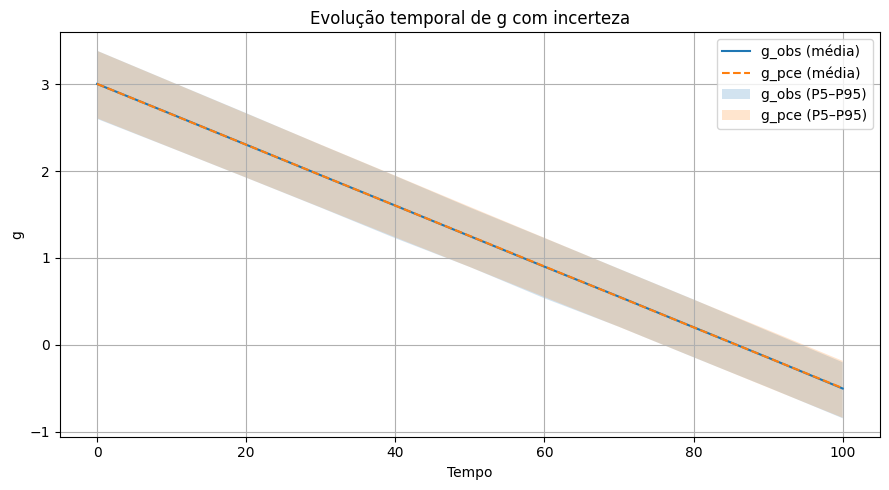

In [21]:
plt.figure(figsize=(9, 5))

# Médias
plt.plot(df_summary["time"], df_summary["g_obs_mean"], label="g_obs (média)")
plt.plot(df_summary["time"], df_summary["g_pce_mean"], label="g_pce (média)", linestyle="--")

# Bandas de incerteza
plt.fill_between(
    df_summary["time"],
    df_summary["g_obs_p05"],
    df_summary["g_obs_p95"],
    alpha=0.2,
    label="g_obs (P5–P95)"
)

plt.fill_between(
    df_summary["time"],
    df_summary["g_pce_p05"],
    df_summary["g_pce_p95"],
    alpha=0.2,
    label="g_pce (P5–P95)"
)

plt.xlabel("Tempo")
plt.ylabel("g")
plt.title("Evolução temporal de g com incerteza")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
